<a href="https://colab.research.google.com/github/yusuf-codes10/deep-learining-project/blob/main/dp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3: brand new day


In [16]:
# STEP 1 — Set Kaggle credentials (run this first)
import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Enter Kaggle username: ")
os.environ['KAGGLE_API_TOKEN'] = getpass("Enter Kaggle API key: ")

KeyboardInterrupt: Interrupted by user

In [ ]:
# STEP 2 — Install Kaggle (run once per session)
!pip install -q kaggle

In [ ]:
# STEP 3 — Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [15]:
# STEP 4 — Unzip dataset
!unzip -q chest-xray-pneumonia.zip

replace chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# EDA

In [17]:

import os

base_path = "chest_xray"

for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()} FOLDER:")
    for label in os.listdir(os.path.join(base_path, split)):
        count = len(os.listdir(os.path.join(base_path, split, label)))
        print(f"  {label}: {count} images")


TRAIN FOLDER:
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

VAL FOLDER:
  NORMAL: 8 images
  PNEUMONIA: 8 images

TEST FOLDER:
  NORMAL: 234 images
  PNEUMONIA: 390 images


**Note**
Dataset is already imnalanced, we have to shuffle and balance it...

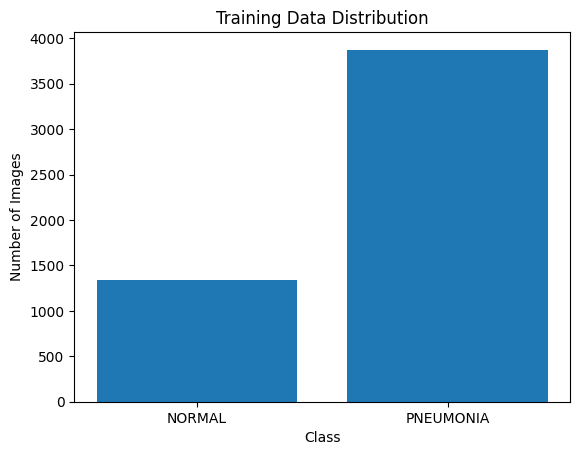

In [18]:
import matplotlib.pyplot as plt

train_counts = {'NORMAL': 1341, 'PNEUMONIA': 3875}

plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Data Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

## Step2 Show sample images

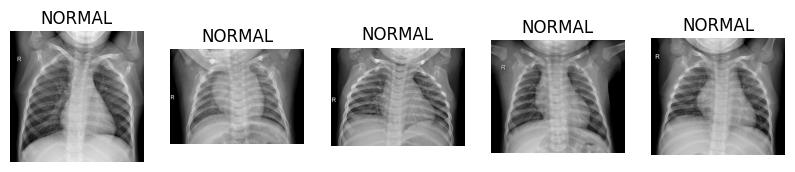

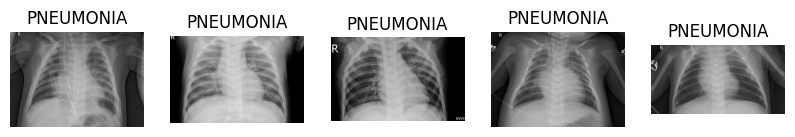

In [19]:
import matplotlib.pyplot as plt
import cv2
import os

def show_samples(base_path, split, label):
    path = os.path.join(base_path, split, label)
    images = os.listdir(path)[:5]  # show 5 images

    plt.figure(figsize=(10, 3))

    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')

    plt.show()

show_samples(base_path, 'train', 'NORMAL')
show_samples(base_path, 'train', 'PNEUMONIA')

**Note**  
Images are clear, mostly, and some of them do not have the same size